In [1]:
import torchvision
import torch
torch.set_printoptions(sci_mode=False, precision=4)

In [2]:
train = torchvision.datasets.MNIST("./data", download=True, train=True, transform=torchvision.transforms.ToTensor())
test = torchvision.datasets.MNIST("./data", download=True, train=False, transform=torchvision.transforms.ToTensor())
train, test

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [3]:
train.data, train.data.shape

(tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         ...,
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0

In [4]:
train.train_labels, test.test_labels

/mnt/ssd1/ResearchPortfolio/PaperFromScratchSeries/VAE/.venv/lib/python3.14/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/mnt/ssd1/ResearchPortfolio/PaperFromScratchSeries/VAE/.venv/lib/python3.14/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


(tensor([5, 0, 4,  ..., 5, 6, 8]), tensor([7, 2, 1,  ..., 4, 5, 6]))

In [5]:
for a, b in train:
    print(a, b)
    print(type(a), type(b))
    break

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

# 2. Data Loader

In [6]:
from torch.utils.data import DataLoader

train_dataset = DataLoader(train, batch_size=128, shuffle=True)
test_dataset = DataLoader(test, batch_size=128, shuffle=False)
train_dataset, test_dataset

(<torch.utils.data.dataloader.DataLoader at 0x7003c4f11fd0>,
 <torch.utils.data.dataloader.DataLoader at 0x7003c4f08a50>)

In [7]:
type(train_dataset.dataset.data)

torch.Tensor

In [8]:
next(iter(train_dataset))[0].shape, next(iter(train_dataset))[1].shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [9]:
# 

# 3. VAE from Scratch

In [10]:
trainData = train.data.reshape(train.data.shape[0], -1)
trainData = (trainData != 0) * 1.0

In [11]:
trainData[0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 0., 0., 0., 0., 0., 

In [12]:
# latent-dimension
J = 2

In [13]:
import torch.nn as nn

# TODO
# 1. Add activation

class Encoder(nn.Module):
    def __init__(self, J):
        super(Encoder, self).__init__()

        self.w1 = nn.Parameter(torch.randn(500, 784))
        self.b1 = nn.Parameter(torch.randn(500))

        self.w2 = nn.Parameter(torch.randn(2*J, 500))
        self.b2 = nn.Parameter(torch.randn(2*J))

    def forward(self, x):
        self.out = torch.tanh(self.w1 @ x + self.b1)
        self.out = torch.tanh(self.w2 @ self.out + self.b2)
        return self.out

    def parameter(self):
        return [self.w1, self.b1, self.w2, self.b2]

class Reparametrizer(nn.Module):
    # R^(2J) -> R^J
    def __init__(self, J):
        super(Reparametrizer, self).__init__()

        self.J = J
        

    def forward(self, x):
        # Not Learnable, only for pure randomness
        epsilon = torch.randn(self.J)
        self.out = x[:J] + x[J:] * epsilon
        return self.out

    def parameter(self):
        return []


class Decoder(nn.Module):
    def __init__(self, J):
        super(Decoder, self).__init__()

        self.w1 = nn.Parameter(torch.randn(500, 2))
        self.b1 = nn.Parameter(torch.randn(500))

        self.w2 = nn.Parameter(torch.randn(784, 500))
        self.b2 = nn.Parameter(torch.randn(784))

    def forward(self, x):
        self.out = torch.tanh(self.w1 @ x + self.b1)
        self.out = torch.sigmoid(self.w2 @ self.out + self.b2)
        return self.out


    def parameter(self):
        return [self.w1, self.b1, self.w2, self.b2]

In [14]:
train.data[0].flatten().shape

torch.Size([784])

In [15]:
torch.manual_seed(42)

e = Encoder(J)
x = trainData[0]
distParamZ = e(x)
distParamZ

tensor([ 0.9981,  1.0000, -1.0000,  0.9999], grad_fn=<TanhBackward0>)

In [16]:
r = Reparametrizer(J)
z = r(distParamZ)
z

tensor([ 0.4952, -1.0687], grad_fn=<AddBackward0>)

In [17]:
d = Decoder(J)
decodedX = d(z)
decodedX

tensor([0.2504, 0.0000, 0.0000, 0.0001, 0.0038, 0.1821, 1.0000, 0.1605, 1.0000,
        0.0000, 0.4217, 1.0000, 0.9917, 0.0000, 1.0000, 0.9921, 0.9996, 1.0000,
        0.0000, 0.0000, 0.0000, 0.9988, 1.0000, 0.0003, 0.0000, 1.0000, 1.0000,
        0.0000, 0.9937, 1.0000, 0.9995, 0.9993, 1.0000, 1.0000, 1.0000, 1.0000,
        0.0000, 0.0001, 0.0000, 0.0000, 0.0389, 0.9997, 0.0004, 0.5038, 0.0004,
        0.9999, 1.0000, 0.2697, 0.8332, 0.0000, 0.0015, 0.9999, 0.9993, 0.0000,
        1.0000, 0.0000, 1.0000, 0.9743, 0.0000, 0.0000, 0.9908, 0.0000, 1.0000,
        0.0008, 0.4996, 0.1009, 0.9972, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 0.0000, 0.0404, 0.0000, 1.0000, 1.0000, 0.9996, 1.0000,
        0.0000, 0.0433, 0.0000, 0.2354, 0.6063, 0.2270, 0.0000, 0.0000, 1.0000,
        0.0001, 0.6932, 1.0000, 0.2086, 1.0000, 1.0000, 1.0000, 0.0000, 0.0796,
        0.9949, 1.0000, 0.4505, 0.9961, 1.0000, 0.0000, 0.3668, 0.0004, 0.9584,
        0.9535, 0.0000, 0.0008, 1.0000, 

In [18]:
output = decodedX.reshape(train.data.shape[1], -1)

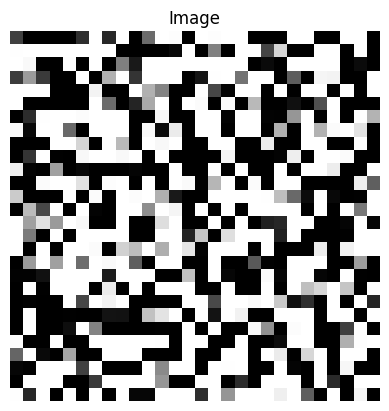

In [19]:
import matplotlib.pyplot as plt

def plot_mnist(image, title="Image"):
    plt.imshow(image.detach().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_mnist(output)

# 4. Comparison of Before and After

## 4.1 Before VAE

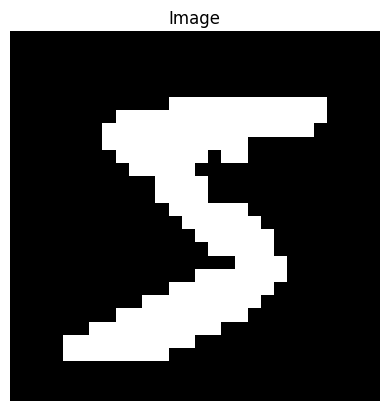

In [20]:
plot_mnist(trainData[0].reshape(train.data.shape[1], -1))

## 4.2 After VAE

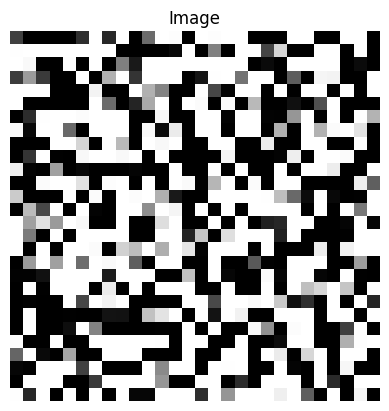

In [21]:
plot_mnist(output)

## Network hasn't learnt anything yet

# 5.Loss Calculation

In [22]:
# Whole, mean, sigma
# distParamZ, distParamZ[:J], distParamZ[J:]
meanVector = distParamZ[:J]
stdVector = distParamZ[J:]
distParamZ, meanVector, stdVector

(tensor([ 0.9981,  1.0000, -1.0000,  0.9999], grad_fn=<TanhBackward0>),
 tensor([0.9981, 1.0000], grad_fn=<SliceBackward0>),
 tensor([-1.0000,  0.9999], grad_fn=<SliceBackward0>))

In [23]:
meanVector = distParamZ[:J]
stdVector = distParamZ[J:]
KLLoss = 0.5 * (1 + torch.log(stdVector ** 2) - (meanVector ** 2) - (stdVector ** 2)).sum()
safety = 1e-4
DecoderLoss = ((trainData[0] * torch.log(decodedX + safety)) + ((1 - trainData[0]) * torch.log(1 - decodedX + safety))).sum()
elbo = KLLoss + DecoderLoss
Loss = -elbo
Loss

tensor(2972.5134, grad_fn=<NegBackward0>)

In [24]:
# parameters -= 0.01 * parameters.grad
vaeParameters = e.parameter() + r.parameter() + d.parameter()
vaeParameters

[Parameter containing:
 tensor([[ 1.9269,  1.4873,  0.9007,  ...,  0.7693, -0.7669, -0.9495],
         [ 0.0169,  0.0803,  0.7448,  ...,  0.4134,  0.0062, -0.5673],
         [-0.1704, -0.3028, -1.2868,  ...,  1.1618,  0.6347, -0.4325],
         ...,
         [ 0.6608,  1.0463, -0.3072,  ..., -0.0023,  1.1003,  0.6708],
         [ 0.5366, -0.4356, -1.4021,  ..., -0.4490, -0.3338,  0.3031],
         [ 1.5311,  0.4876,  1.4386,  ..., -0.4394, -0.8412,  0.4955]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.5750, -0.8992,  1.1926, -1.2382,  0.1740, -0.8891, -0.4849, -1.0695,
         -0.4144, -0.1858,  0.3748,  1.2230, -0.2757, -0.8171,  0.8930, -2.1029,
          0.1543, -1.3014, -0.8583,  0.5189, -0.1677, -1.3352,  1.4899,  1.2888,
          0.2134, -1.1936,  0.0201, -1.6494,  0.0066, -1.8395,  0.1941, -1.8141,
          1.1561,  0.6183,  1.6258,  0.2313, -1.3037, -0.6407,  0.6576, -1.1667,
         -0.8063, -0.7011,  0.4240,  0.8908,  1.8493,  0.4302,  0.3884, -1.3023

In [25]:
# Flush gradient
for parameter in vaeParameters:
    parameter.grad = None

# Backprop
Loss.backward()

In [26]:
# parameter -= 0.01 * parameter.grad
for parameter in vaeParameters:
    parameter.data -= 0.01 * parameter.grad

In [27]:
vaeParameters

[Parameter containing:
 tensor([[ 1.9269,  1.4873,  0.9007,  ...,  0.7693, -0.7669, -0.9495],
         [ 0.0169,  0.0803,  0.7448,  ...,  0.4134,  0.0062, -0.5673],
         [-0.1704, -0.3028, -1.2868,  ...,  1.1618,  0.6347, -0.4325],
         ...,
         [ 0.6608,  1.0463, -0.3072,  ..., -0.0023,  1.1003,  0.6708],
         [ 0.5366, -0.4356, -1.4021,  ..., -0.4490, -0.3338,  0.3031],
         [ 1.5311,  0.4876,  1.4386,  ..., -0.4394, -0.8412,  0.4955]],
        requires_grad=True),
 Parameter containing:
 tensor([-0.5750, -0.8992,  1.1926, -1.2382,  0.1740, -0.8891, -0.4834, -1.0695,
         -0.4145, -0.1858,  0.3748,  1.2238, -0.2757, -0.8171,  0.8930, -2.1027,
          0.1543, -1.3014, -0.8583,  0.5189, -0.1677, -1.3353,  1.4898,  1.2888,
          0.2134, -1.1936,  0.0201, -1.6489,  0.0066, -1.8395,  0.1873, -1.8141,
          1.1580,  0.6183,  1.6258,  0.2313, -1.3037, -0.6407,  0.6576, -1.1667,
         -0.8063, -0.7011,  0.4240,  0.8908,  1.8503,  0.4302,  0.3884, -1.3016

In [28]:
# Full Training Loop
torch.manual_seed(42)

e = Encoder(J)
r = Reparametrizer(J)
d = Decoder(J)

vaeParameters = e.parameter() + r.parameter() + d.parameter()

Losses = []


for i in range(1000):

    x = trainData[0]

    # 1. Forward

    distParamZ = e(x)
    z = r(distParamZ)  
    decodedX = d(z)


    # 2. Calculate Loss

    meanVector = distParamZ[:J]
    stdVector = distParamZ[J:]
    KLLoss = 0.5 * (1 + torch.log(stdVector ** 2) - (meanVector ** 2) - (stdVector ** 2)).sum()
    safety = 1e-4
    DecoderLoss = ((trainData[0] * torch.log(decodedX + safety)) + ((1 - trainData[0]) * torch.log(1 - decodedX + safety))).sum()
    elbo = KLLoss + DecoderLoss
    Loss = -elbo

    print(f"{i:04d}th epoch: {Loss=}")
    Losses.append(Loss.data)


    # 3. Backward

    # 3.1 Flush Gradient
    for parameter in vaeParameters:
        parameter.grad = None
    
    # 3.2 Loss Backward
    Loss.backward()

    

    # 3.3 Update Parameters
    for parameter in vaeParameters:
        parameter.data -= 0.01 * parameter.grad


0000th epoch: Loss=tensor(3032.5693, grad_fn=<NegBackward0>)
0001th epoch: Loss=tensor(2782.6272, grad_fn=<NegBackward0>)
0002th epoch: Loss=tensor(2543.7639, grad_fn=<NegBackward0>)
0003th epoch: Loss=tensor(2144.4155, grad_fn=<NegBackward0>)
0004th epoch: Loss=tensor(2062.7959, grad_fn=<NegBackward0>)
0005th epoch: Loss=tensor(1953.1942, grad_fn=<NegBackward0>)
0006th epoch: Loss=tensor(2147.5190, grad_fn=<NegBackward0>)
0007th epoch: Loss=tensor(1732.0072, grad_fn=<NegBackward0>)
0008th epoch: Loss=tensor(1620.2435, grad_fn=<NegBackward0>)
0009th epoch: Loss=tensor(1574.9811, grad_fn=<NegBackward0>)
0010th epoch: Loss=tensor(1326.4733, grad_fn=<NegBackward0>)
0011th epoch: Loss=tensor(1321.5977, grad_fn=<NegBackward0>)
0012th epoch: Loss=tensor(1134.0244, grad_fn=<NegBackward0>)
0013th epoch: Loss=tensor(1084.3691, grad_fn=<NegBackward0>)
0014th epoch: Loss=tensor(1112.5256, grad_fn=<NegBackward0>)
0015th epoch: Loss=tensor(1077.1232, grad_fn=<NegBackward0>)
0016th epoch: Loss=tenso

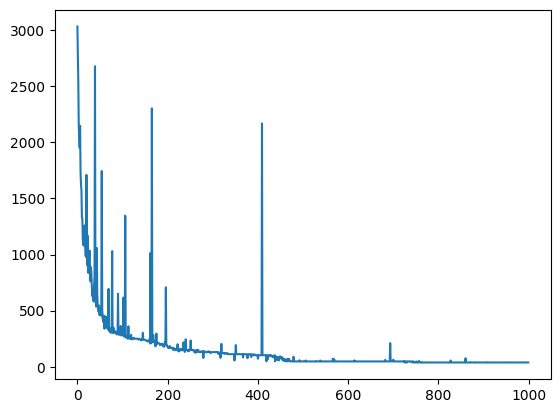

In [29]:
plt.plot(Losses)

### Why is there an occasional spikes?
### Answer: It is because of the the randomness from reparameterization sampling epsilon from normal disitrbution

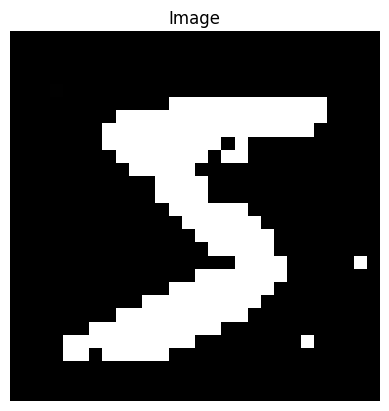

In [30]:
# Image generation Inference after training (on 1 image lol)

# One liner
# z ~ N(0, I), z is member of R^2 sampled from 2D multivariate gaussian distribution
z = torch.randn(2)
decodedX = d(z)

# Reshape the output
output = decodedX.reshape(train.data.shape[1], -1)
plot_mnist(output)

Real problems (in priority order)
1. You're predicting σ directly, but passing it through tanh. This is the biggest issue.
pythonself.out = torch.tanh(self.w2 @ self.out + self.b2)  # both μ and σ

tanh bounds μ to [−1, 1]. μ must be unbounded, otherwise your latent space is a tiny box and the model can't separate classes.
tanh lets σ go negative, which is nonsense for a standard deviation. It happens to not crash because σ gets squared in the KL and mu + std*eps is symmetric in eps's sign — but it's a landmine waiting to fire.
Standard fix: predict log_var (unbounded, linear output), then use std = exp(0.5 * log_var) in reparam and KL = -0.5 * sum(1 + log_var - μ² - exp(log_var)). This is the universal convention for a reason — numerical stability and unbounded μ.

2. You're training on one image. x = trainData[0] lives inside the loop. You know this ("on 1 image lol"), but it means: this isn't a VAE yet, it's a 1-example autoencoder with stochastic noise. The KL term doesn't really do its job (regularizing the aggregate posterior) until you have a batch + dataset diversity. Your immediate next step is batching.
3. Your forward pass can't actually batch. self.w1 @ x + self.b1 works for a 1D vector. For a batch (B, 784) you need x @ self.w1.T + self.b1. This is why you're stuck on one sample. Fix this and (2) becomes free. Even better: just use nn.Linear — you've already proved you understand what's underneath, no points lost for using it now.
4. Weight init is torch.randn — way too large. For a 784→500 layer, randn weights give pre-activations with std ≈ √784 ≈ 28. That saturates tanh immediately and kills gradients in the first layer. You're getting away with it because of the trivial 1-sample task. Use Xavier (nn.init.xavier_uniform_) or just nn.Linear which does it for you. Once you batch on the full dataset, this will bite hard.
5. safety = 1e-4 in the BCE. Too large — it shifts the loss landscape noticeably. Standard is 1e-7/1e-8, but the correct fix is to make the decoder output logits (no sigmoid) and use F.binary_cross_entropy_with_logits, which is numerically stable by construction. This is one of those "every practitioner switches to this within a month" things.
6. KL/recon reduction isn't normalized. Both your terms use .sum(), which is fine and consistent on a single image. But once you batch, decide explicitly: sum over pixels & latent dims, then mean over batch. Mixing sum and mean between the two terms is the #1 way people accidentally implement β-VAE without realizing it and then wonder why their reconstructions are blurry / posterior collapses.
7. You never actually test the generative side. The whole point of a VAE over an AE is sampling z ~ N(0, I) and decoding. You only ever decode z = encode(x). Once you've batch-trained, add: sample 64 z's from the prior, decode, plot the grid. With latent dim 2 also do the classic "scan a 2D grid in latent space and decode each point" — this is the visualization that makes the manifold click and is genuinely beautiful on MNIST.
What I'd do for v2 (concrete checklist)

Switch encoder to predict (μ, log_var) with linear output, not tanh.
Rewrite forward with batch-first matmul (or nn.Linear).
Train on the full dataset, batch 128, ~20 epochs, Adam(1e-3).
Use BCE-with-logits, drop the safety epsilon.
Plot: (a) recon pairs, (b) prior samples, (c) 2D latent grid scan, (d) latent scatter colored by digit class.
Sanity check: KL should rise from ~0 then stabilize, recon should fall. If KL crashes to 0 → posterior collapse (won't happen at z-dim 2, but good habit).